In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Load Data From Kaggle
https://www.kaggle.com/datasets/datascikhan/e-commerce-customer-segmentation-2026

In [42]:
from pathlib import Path

path = kagglehub.dataset_download(
    "datascikhan/e-commerce-customer-segmentation-2026"
)
print("Path to dataset files:", path)

data_dir = Path(path)
csv_files = list(data_dir.rglob("*.csv"))

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {data_dir}")

df = pd.read_csv(csv_files[0])

Path to dataset files: /Users/yezawmyint/.cache/kagglehub/datasets/datascikhan/e-commerce-customer-segmentation-2026/versions/1


# Understanding data

In [91]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
# Check Duplication
duplicate_count = df.duplicated().sum()
print(f"Duplicate Rows: {duplicate_count:,}\n")

# Column Information
print("*"*30)
print(" Column Information")
print("*"*30)

column_info = pd.DataFrame({
    "Column": df.columns.astype(str).values,
    "Data Type": df.dtypes.astype(str).values,
    "Duplicate": df.duplicated().sum()
})

display(column_info)

Rows: 50,000
Columns: 58
Duplicate Rows: 0

******************************
 Column Information
******************************


,Column,Data Type,Duplicate
0,customer_id,str,0
1,customer_segment,str,0
2,segment_category,str,0
3,age,int64,0
4,age_group,str,0
5,gender,str,0
6,country,str,0
7,city,str,0
8,income_bracket,str,0
9,education_level,str,0


## Check Data Validation

In [44]:
# Missing values
missing = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing,
    "Missing %": (missing / len(df) * 100).round(2)
})
print("*"*30)
print(" Missing Value Summary")
print("*"*30)

display(
    missing_summary
    .sort_values("Missing Values", ascending=False)
    .head(10)
)

******************************
 Missing Value Summary
******************************


,Missing Values,Missing %
preferred_category_3,33257,66.51
preferred_category_2,16743,33.49
social_media_presence,12420,24.84
loyalty_tier,1272,2.54
customer_id,0,0.00
rfm_score,0,0.00
click_through_rate,0,0.00
conversion_rate,0,0.00
customer_lifetime_value_usd,0,0.00
customer_acquisition_cost_usd,0,0.00


In [ ]:
# Check Duplication
duplicate_count = df.duplicated().sum()
print(f"Duplicate Rows: {duplicate_count:,}")


Duplicate Rows: 0


In [77]:
summary_cols = [
    "age",
    "tenure_months",
    "total_purchases",
    "avg_order_value_usd",
    "total_spent_usd",
    "days_since_last_purchase"
]

display(
    df[summary_cols]
    .describe()
    .T
    .round(2)
)

,count,mean,std,min,25%,50%,75%,max
age,50000.0,45.65,18.37,18.00,30.00,45.00,60.00,84.00
tenure_months,50000.0,59.75,34.31,1.00,30.00,60.00,90.00,119.00
total_purchases,50000.0,99.42,57.78,0.00,49.00,99.00,150.00,199.00
avg_order_value_usd,50000.0,505.37,285.60,10.05,259.07,504.79,752.70,999.99
total_spent_usd,50000.0,50266.55,44071.21,0.00,13893.58,37541.62,76811.24,198574.14
days_since_last_purchase,50000.0,62.97,93.28,0.00,2.00,19.00,77.00,365.00


In [48]:
# Top 5 rows
df.head()

,customer_id,customer_segment,segment_category,age,age_group,gender,country,city,income_bracket,education_level,...,customer_value_category,activity_status,health_status,churn_risk_category,rfm_category,profitability_category,engagement_level,behavior_segment,device_preference,clv_category
0,CUST-000001,Consumer,High Value Inactive,70,65+,Male,Canada,Winnipeg,150K+,Professional,...,High,Dormant,Excellent,Low,Potential Loyalists,High Profit,Low,Regular Buyer,Multi-Device,High CLV
1,CUST-000002,Premium,High Value Inactive,53,45-54,Female,Germany,Essen,25K-50K,High School,...,Medium,Inactive,Excellent,Medium,At Risk,High Profit,Low,Occasional Buyer,Desktop-First,High CLV
2,CUST-000003,Consumer,High Value Inactive,82,65+,Male,Mexico,Puebla,75K-100K,Bachelors,...,Very High,Dormant,Excellent,Very Low,Champions,High Profit,Low,Regular Buyer,Multi-Device,High CLV
3,CUST-000004,Enterprise,High Value Active,18,18-24,Male,Singapore,Singapore,150K+,Masters,...,Very High,Active,Excellent,Very Low,Champions,High Profit,High,Frequent Buyer,Mobile-First,High CLV
4,CUST-000005,Premium,High Value Active,64,55-64,Male,United Arab Emirates,Fujairah,150K+,PhD,...,Medium,Active,Fair,Medium,Loyal,High Profit,Medium,Occasional Buyer,Desktop-First,High CLV


In [49]:
# Bottom 5 rows
df.tail()

,customer_id,customer_segment,segment_category,age,age_group,gender,country,city,income_bracket,education_level,...,customer_value_category,activity_status,health_status,churn_risk_category,rfm_category,profitability_category,engagement_level,behavior_segment,device_preference,clv_category
49995,CUST-049996,Small Business,Low Value,22,18-24,Female,United States,San Antonio,50K-75K,PhD,...,Very Low,Inactive,Fair,High,Need Attention,High Profit,Low,Occasional Buyer,Multi-Device,Low CLV
49996,CUST-049997,Small Business,High Value Inactive,24,18-24,Male,Brazil,Rio de Janeiro,25K-50K,PhD,...,Very High,Dormant,Excellent,Low,Champions,High Profit,Medium,Regular Buyer,Multi-Device,High CLV
49997,CUST-049998,Consumer,High Value Inactive,29,25-34,Female,France,Strasbourg,100K-150K,Bachelors,...,Very High,Dormant,Excellent,Very Low,Champions,High Profit,Low,Regular Buyer,Multi-Device,High CLV
49998,CUST-049999,Consumer,High Value Active,74,65+,Male,Italy,Catania,100K-150K,Bachelors,...,High,Active,Good,Low,Champions,High Profit,Low,Frequent Buyer,Multi-Device,High CLV
49999,CUST-050000,Consumer,High Value Inactive,77,65+,Female,United Arab Emirates,Sharjah,75K-100K,Masters,...,Very High,Inactive,Excellent,Low,Loyal,High Profit,Low,Occasional Buyer,Desktop-First,High CLV


# Exploratory Data Analysis

This section looks at the customers, their purchase activity, and simple patterns in the data.

## Descriptive Statistics

First, I summarize the main customer and purchase variables before looking at charts.

### Customer Profile

This part shows who the customers are by age group, gender, income, country, and device.

In [68]:
customer_profile_summary = pd.DataFrame({
    "Metric": [
        "Unique customers",
        "Most common age group",
        "Most common gender",
        "Most common income bracket",
        "Top country",
        "Most used device"
    ],
    "Value": [
        df["customer_id"].nunique(),
        df["age_group"].mode().iat[0],
        df["gender"].mode().iat[0],
        df["income_bracket"].mode().iat[0],
        df["country"].mode().iat[0],
        df["device_used"].mode().iat[0]
    ]
})

display(customer_profile_summary)

,Metric,Value
0,Unique customers,50000
1,Most common age group,65+
2,Most common gender,Female
3,Most common income bracket,0-25K
4,Top country,United States
5,Most used device,Desktop


In [51]:
plt.style.use('ggplot')

In [52]:
def show_fig():
    plt.tight_layout()
    plt.show()
plot_no = 1

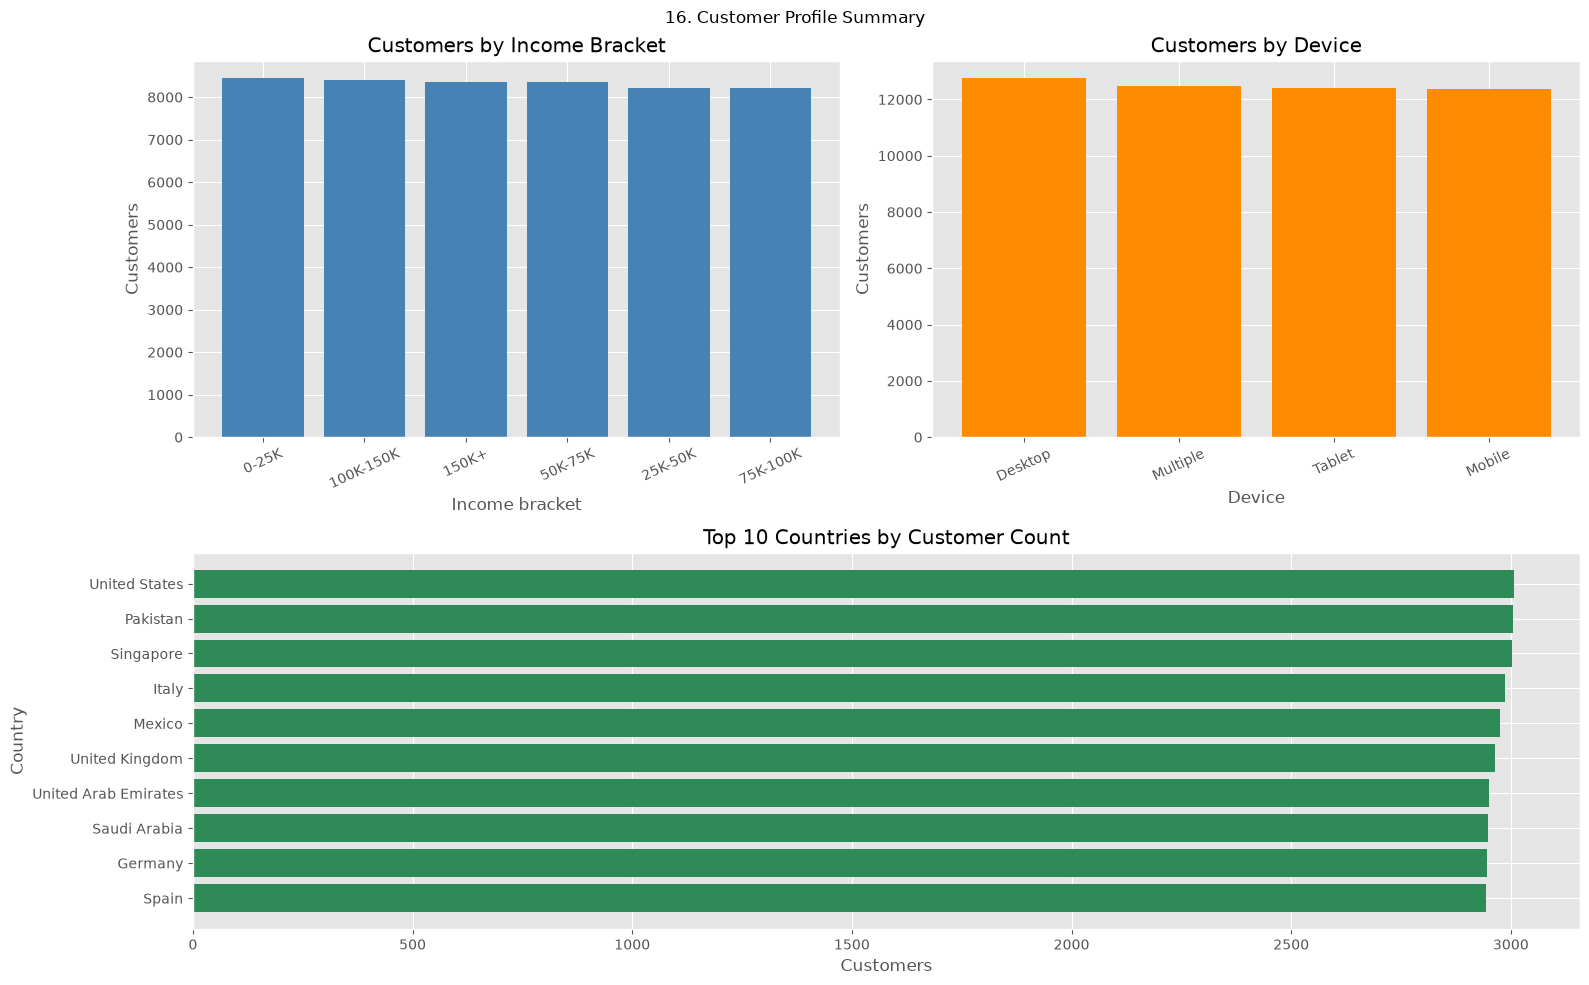

In [78]:
fig = plt.figure(figsize=(16, 10))
grid = fig.add_gridspec(2, 2)

income_ax = fig.add_subplot(grid[0, 0])
income_counts = df["income_bracket"].value_counts()
income_ax.bar(income_counts.index, income_counts.values, color="steelblue")
income_ax.set_title("Customers by Income Bracket")
income_ax.set_xlabel("Income bracket")
income_ax.set_ylabel("Customers")
income_ax.tick_params(axis="x", rotation=25)


device_ax = fig.add_subplot(grid[0, 1])
device_counts = df["device_used"].value_counts()
device_ax.bar(device_counts.index, device_counts.values, color="darkorange")
device_ax.set_title("Customers by Device")
device_ax.set_xlabel("Device")
device_ax.set_ylabel("Customers")
device_ax.tick_params(axis="x", rotation=25)


country_ax = fig.add_subplot(grid[1, :])
country_counts = df["country"].value_counts().head(10).sort_values()
country_ax.barh(country_counts.index, country_counts.values, color="seagreen")
country_ax.set_title("Top 10 Countries by Customer Count")
country_ax.set_xlabel("Customers")
country_ax.set_ylabel("Country")

fig.suptitle(f"{plot_no}. Customer Profile Summary")
plot_no += 1
show_fig()

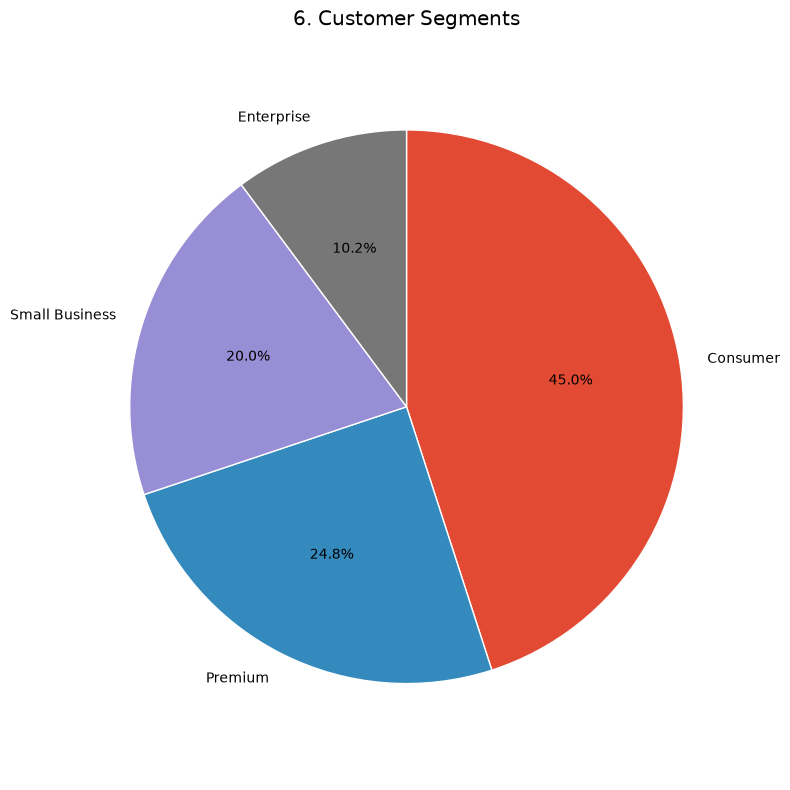

In [65]:
plt.figure(figsize=(8, 8))
segment_counts = df["customer_segment"].value_counts()

plt.pie(
    segment_counts.values,
    labels=segment_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    wedgeprops={"edgecolor": "white", "linewidth": 1}
)

plt.title(f"{plot_no}. Customer Segments")
plt.axis("equal")
show_fig()
plot_no += 1

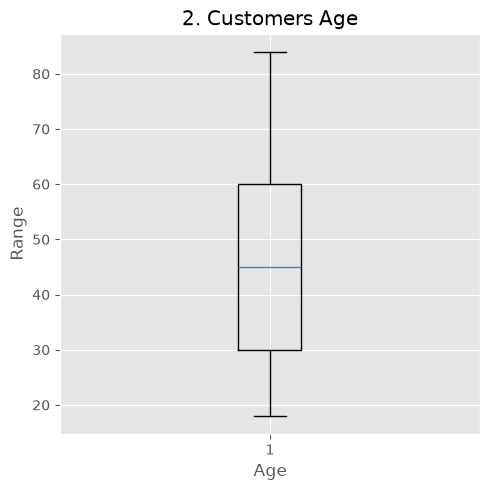

In [54]:
# Outliers
plt.figure(figsize=(5,5))
plt.boxplot(df['age'], showfliers=True)
plt.xlabel("Age")
plt.ylabel("Range")
plt.title(f'{plot_no}. Customers Age')
show_fig()
plot_no+=1

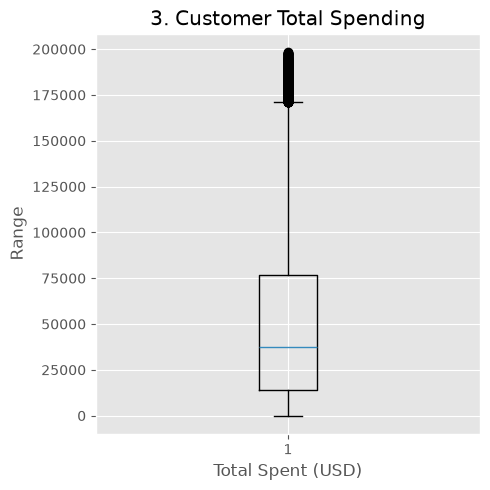

In [55]:
# Outliers in total spending
plt.figure(figsize=(5, 5))
plt.boxplot(df["total_spent_usd"], showfliers=True)

plt.xlabel("Total Spent (USD)")
plt.ylabel("Range")
plt.title(f"{plot_no}. Customer Total Spending")
show_fig()
plot_no += 1

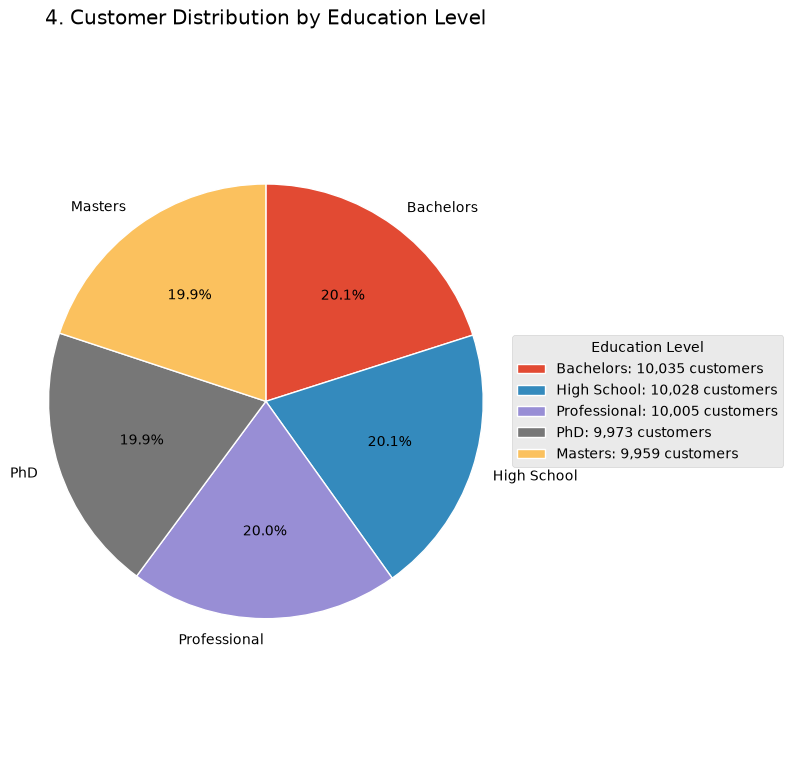

In [56]:
education_counts = df["education_level"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    education_counts.values,
    labels=education_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    wedgeprops={"edgecolor": "white", "linewidth": 1}
)

plt.title(f"{plot_no}. Customer Distribution by Education Level")
plt.legend(
    title="Education Level",
    labels=[
        f"{level}: {count:,} customers"
        for level, count in education_counts.items()
    ],
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.axis("equal")
show_fig()
plot_no += 1

### Purchase Behavior

This part summarizes how often customers purchase, how much they spend, and how recently they purchased.

In [70]:
purchase_cols = [
    "tenure_months",
    "total_purchases",
    "avg_order_value_usd",
    "total_spent_usd",
    "purchase_frequency",
    "days_since_last_purchase"
]

purchase_summary = pd.DataFrame({
    "Metric": [
        "Average tenure (months)",
        "Average total purchases",
        "Average order value (USD)",
        "Average total spent (USD)",
        "Average days since last purchase"
    ],
    "Value": [
        df["tenure_months"].mean(),
        df["total_purchases"].mean(),
        df["avg_order_value_usd"].mean(),
        df["total_spent_usd"].mean(),
        df["days_since_last_purchase"].mean()
    ]
})

purchase_summary["Value"] = purchase_summary["Value"].round(2)
display(purchase_summary)

,Metric,Value
0,Average tenure (months),59.75
1,Average total purchases,99.42
2,Average order value (USD),505.37
3,Average total spent (USD),50266.55
4,Average days since last purchase,62.97


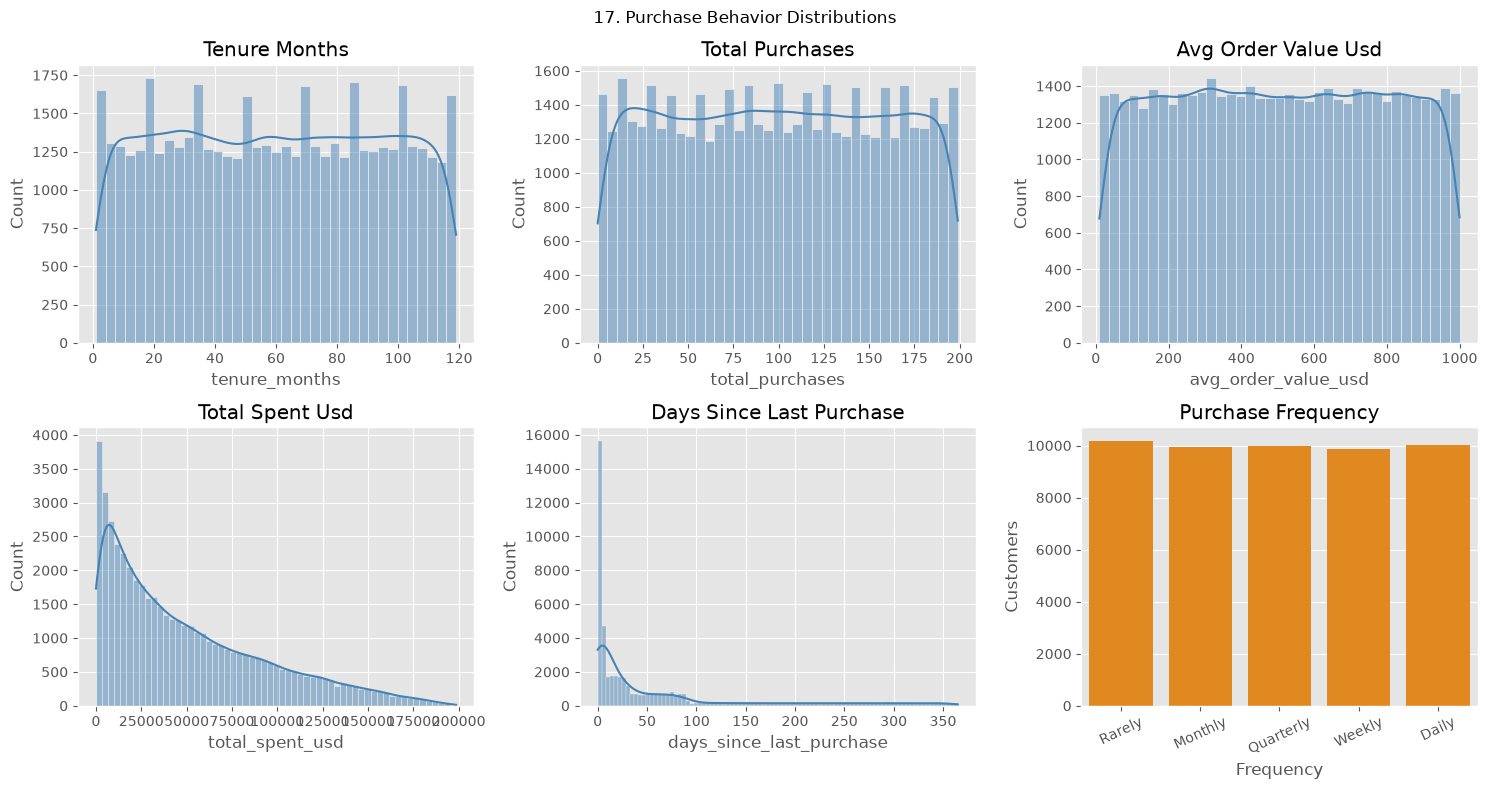

In [79]:
numeric_purchase_cols = [
    "tenure_months",
    "total_purchases",
    "avg_order_value_usd",
    "total_spent_usd",
    "days_since_last_purchase"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, column in zip(axes.flat[:5], numeric_purchase_cols):
    sns.histplot(df[column], kde=True, ax=ax, color="steelblue")
    ax.set_title(column.replace("_", " ").title())

frequency_order = ["Rarely", "Monthly", "Quarterly", "Weekly", "Daily"]
sns.countplot(
    data=df,
    x="purchase_frequency",
    order=[value for value in frequency_order if value in df["purchase_frequency"].unique()],
    ax=axes[1, 2],
    color="darkorange"
)
axes[1, 2].set_title("Purchase Frequency")
axes[1, 2].set_xlabel("Frequency")
axes[1, 2].set_ylabel("Customers")
axes[1, 2].tick_params(axis="x", rotation=25)

fig.suptitle(f"{plot_no}. Purchase Behavior Distributions")
plot_no += 1
show_fig()

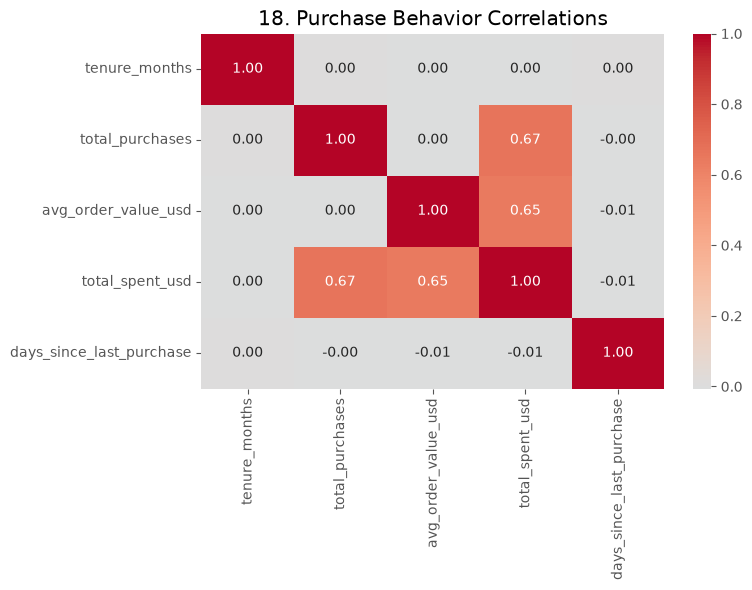

In [80]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df[numeric_purchase_cols].corr(),
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title(f"{plot_no}. Purchase Behavior Correlations")
show_fig()
plot_no += 1

In [71]:
frequency_order = {
    "Rarely": 1,
    "Monthly": 2,
    "Quarterly": 3,
    "Weekly": 4,
    "Daily": 5
}

frequency_numeric = (
    df["purchase_frequency"]
    .astype("string")
    .str.strip()
    .map(frequency_order)
)

if frequency_numeric.isna().any():
    unexpected = df.loc[
        frequency_numeric.isna(),
        "purchase_frequency"
    ].dropna().unique().tolist()
    raise ValueError(f"Unexpected values: {unexpected}")

df["frequency_group"] = pd.qcut(
    frequency_numeric.rank(method="first"),
    3,
    labels=["Low", "Medium", "High"]
)

df["recency_group"] = pd.qcut(
    df["days_since_last_purchase"],
    3,
    labels=["Recent", "Moderate", "Inactive"],
    duplicates="drop"
)

behavior_summary = (
    df.groupby(["frequency_group", "recency_group"], observed=True)
    .agg(
        customers=("customer_id", "nunique"),
        avg_spent=("total_spent_usd", "mean"),
        avg_order_value=("avg_order_value_usd", "mean")
    )
    .reset_index()
)

behavior_summary[["avg_spent", "avg_order_value"]] = (
    behavior_summary[["avg_spent", "avg_order_value"]].round(2)
)

display(behavior_summary)

,frequency_group,recency_group,customers,avg_spent,avg_order_value
0,Low,Moderate,6483,50101.01,508.19
1,Low,Inactive,10184,49760.75,499.88
2,Medium,Recent,2304,52083.72,517.58
3,Medium,Moderate,8028,50284.57,502.47
4,Medium,Inactive,6334,50884.86,509.45
5,High,Recent,14774,50146.03,505.16
6,High,Moderate,1893,50138.06,510.57
